In [1]:
import pandas as pd

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "../../")

from spec.enums import MainTableColumns as Cols

In [2]:
# base_dir = '../../../sample_data/cwo/s19/analysis/'
# base_dir = '../../../sample_data/cwo/f19/analysis/'
base_dir = '../../../sample_data/codebench/2024/analysis/'
# base_dir = '../../../sample_data/edwards/2021/analysis/'

In [3]:
data = pd.read_csv(os.path.join(base_dir, 'subject_features.csv'))

In [4]:
data.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,Grade
0,28270295,-0.100588,-0.290208,-0.178658,-0.642665,-0.731621,-0.836568,0.596706,-0.969685,-0.665842,...,-1.056546,-0.968186,1.422852,0.403406,0.377579,0.709004,2.127136,1.857665,-1.030587,7.49
1,30783136,-0.993552,-1.258418,-1.115466,-0.740103,-1.062024,0.005973,0.091336,-0.075839,0.230535,...,-0.004118,0.041295,-0.843265,-0.955538,-0.975029,-0.345680,-0.046994,0.061550,-0.029873,8.31
2,105980555,-0.541978,-0.714607,-0.637945,-0.542461,-0.028987,-1.009072,-0.513831,-1.020542,-0.705742,...,-0.623612,-0.568304,-0.591474,-0.898916,-0.749594,-1.801542,-0.429562,-0.637158,-0.628309,1.25
3,141341221,-0.730157,-0.634318,-0.709504,-0.414701,-0.129385,-0.950560,0.209107,-0.988809,0.147420,...,-0.951952,0.022969,-0.087893,-0.049575,0.095786,-0.575244,-0.334250,-0.409018,0.114009,5.91
4,153511603,0.097531,0.089083,0.106438,-0.073279,-0.519774,-0.089131,0.583240,-0.153101,0.841654,...,-0.124147,1.054828,-0.423614,0.743143,0.659372,0.766900,-1.809747,-1.510994,0.865963,6.48


In [5]:
all_dirs = {
    'Ed_F21': '../../../sample_data/edwards/2021/analysis/',
    'Ed_F19': '../../../sample_data/edwards/2019/analysis-f19/',
    'Ed_S19': '../../../sample_data/edwards/2019/analysis-s19/',
    'CWO_S19': '../../../sample_data/cwo/s19/analysis/',
    'CWO_F19': '../../../sample_data/cwo/f19/analysis/',
    'CB_F24': '../../../sample_data/codebench/2024/analysis/',
    'Eng_S24': '../../../sample_data/CSC111/analysis/',
    'Fal_S21': '../../../sample_data/falconcode/analysis-s21/',
    'Fal_F21': '../../../sample_data/falconcode/analysis-f21/',
    'Fal_S22': '../../../sample_data/falconcode/analysis-s22/',
}

In [6]:
overwrite = False

In [7]:
central_output_dir = '../../../sample_data/feature_importance/'
if overwrite:
    import shutil
    if not os.path.exists(central_output_dir):
        os.makedirs(central_output_dir)
    for name, dir in all_dirs.items():
        file_path = os.path.join(dir, 'subject_features.csv')
        if os.path.exists(file_path):
            # Copy the file to the central output directory
            new_name = f"{name}.csv"
            shutil.copy(file_path, os.path.join(central_output_dir, new_name))

In [8]:
def load_dataset(name):
    file_path = os.path.join(central_output_dir, f"{name}.csv")
    if not os.path.exists(file_path):
        print(f"Skipping missing file: {file_path}")
        return None
    data = pd.read_csv(file_path)
    # There's just one CS course with 18 students, so I don't think it's
    # worth treating as a separate prediction.
    if "X-ClassID" in data.columns:
        data = data[data["X-ClassID"] != 2607741091]
    return data

In [9]:
from scipy.stats import pearsonr, spearmanr

def get_grade_correlations(data):
    skip_cols = ["X-ClassID", Cols.SubjectID, "Grade"]
    skip_cols = [col for col in skip_cols if col in data.columns]
    grades = data["Grade"]
    rows = []
    for col in data.columns:
        if col in skip_cols:
            continue
        corr, p_value = spearmanr(grades, data[col])
        rows.append({"Feature": col, "Rho": corr, "p": p_value})
    return pd.DataFrame(rows)

In [10]:
row_counts = []
all_data = None
for name, dir in all_dirs.items():
    data = load_dataset(name)
    if data is None:
        continue
    row_counts.append({
        "Dataset": name,
        "Unique Students": data[Cols.SubjectID].nunique(),
        "Sections": data["X-ClassID"].nunique() if "X-ClassID" in data.columns else 1,
        "Rows": len(data),
    })

    corrs = get_grade_correlations(data)
    corrs["Dataset"] = name
    if all_data is None:
        all_data = corrs
    else:
        all_data = pd.concat([all_data, corrs], ignore_index=True)
# all_data.sort_values(by="Feature", inplace=True)

# We want the sum instead of the mean for attempted (and to label it clearly)
# So this hack includes it among the other means
all_data["Feature"] = all_data["Feature"].str.replace("Attempted_sum", "Problems Attempted (Total)_mean", regex=False)
all_data["Feature"] = all_data["Feature"].str.replace("Attempted_mean", "Attempted mean", regex=False)

all_data = all_data[all_data["Feature"].str.endswith("_mean")]
all_data["Feature"] = all_data["Feature"].str.replace("_mean", "", regex=False)

ignore_features = [
    # Sort of arbitrary, not from the literature
    "ActiveTimeAfterCorrect",
    # Almost identical to Attempts (just includes after correct)
    "TotalAttempts",
    # These three were new ideas we added but don't add much on top of
    # the base metrics from which they were calculated.
    # Yes, that's a type on AtLeat
    "AtLeatMedianActiveTime",
    "AtLeatMedianMaxScore",
    "HadEffort",
]
all_data = all_data[~all_data["Feature"].isin(ignore_features)]

all_data["Feature"] = pd.Categorical(all_data["Feature"], categories=all_data["Feature"].unique(), ordered=True)
all_data

C:\Users\twprice\AppData\Local\Temp\ipykernel_15956\724434793.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(grades, data[col])
C:\Users\twprice\AppData\Local\Temp\ipykernel_15956\724434793.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(grades, data[col])
C:\Users\twprice\AppData\Local\Temp\ipykernel_15956\724434793.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(grades, data[col])
C:\Users\twprice\AppData\Local\Temp\ipykernel_15956\724434793.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(grades, data[col])


,Feature,Rho,p,Dataset
0,ActiveTime,-0.045122,7.793784e-01,Ed_F21
1,PassiveTime,0.058362,7.170129e-01,Ed_F21
2,TotalTime,0.010105,9.500044e-01,Ed_F21
4,#Breaks,0.287643,6.821085e-02,Ed_F21
5,StartTime,-0.496167,9.697218e-04,Ed_F21
...,...,...,...,...
388,EverCorrect,0.361950,3.440090e-15,Fal_S22
390,MaxScore,0.452655,8.187091e-24,Fal_S22
391,MinScore,0.526038,5.789935e-33,Fal_S22
392,MeanScore,0.540014,5.672503e-35,Fal_S22


In [11]:
pd.DataFrame(row_counts).to_csv(os.path.join(central_output_dir, "row_counts.csv"), index=False)

In [12]:
pd.DataFrame(row_counts)

,Dataset,Unique Students,Sections,Rows
0,Ed_F21,41,1,41
1,Ed_F19,184,1,184
2,Ed_S19,150,1,150
3,CWO_S19,341,1,341
4,CWO_F19,494,1,494
5,CB_F24,189,5,189
6,Eng_S24,55,1,55
7,Fal_S21,482,1,482
8,Fal_F21,621,1,621
9,Fal_S22,444,1,444


In [13]:
heat_map_values = all_data.pivot(index="Feature", columns="Dataset", values="Rho")
p_values = all_data.pivot(index="Feature", columns="Dataset", values="p")

import numpy as np

def significance_marker(p):
    if p < 0.001:
        return "***  "
    elif p < 0.01:
        return "**   "
    elif p < 0.05:
        return "*     "
    else:
        return " (ns)"

sig_marker_vec = np.vectorize(significance_marker)

markers = sig_marker_vec(p_values)
heat_map_annotations = heat_map_values.copy()
heat_map_annotations = heat_map_annotations.applymap(lambda x: f"{x:.2f}" if not pd.isna(x) else pd.NA) + markers

c:\Users\twprice\Documents\GitHub\ProgSnap2\.conda\Lib\site-packages\numpy\lib\_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in significance_marker (vectorized)
  outputs = ufunc(*inputs)
C:\Users\twprice\AppData\Local\Temp\ipykernel_15956\1134270558.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heat_map_annotations = heat_map_annotations.applymap(lambda x: f"{x:.2f}" if not pd.isna(x) else pd.NA) + markers


In [14]:
heat_map_annotations

Dataset,CB_F24,CWO_F19,CWO_S19,Ed_F19,Ed_F21,Ed_S19,Eng_S24,Fal_F21,Fal_S21,Fal_S22
Feature,,,,,,,,,,
ActiveTime,-0.20**,-0.12**,-0.01 (ns),-0.10 (ns),-0.05 (ns),-0.08 (ns),-0.13 (ns),-0.24***,-0.39***,-0.47***
PassiveTime,-0.28***,-0.11*,-0.01 (ns),-0.14 (ns),0.06 (ns),-0.13 (ns),-0.20 (ns),-0.50***,-0.41***,-0.48***
TotalTime,-0.26***,-0.13**,-0.01 (ns),-0.14 (ns),0.01 (ns),-0.11 (ns),-0.17 (ns),-0.48***,-0.45***,-0.53***
#Breaks,-0.16*,-0.10*,-0.02 (ns),-0.20**,0.29 (ns),-0.09 (ns),-0.13 (ns),-0.58***,-0.30***,-0.47***
StartTime,-0.29***,-0.24***,-0.12*,-0.34***,-0.50***,-0.24**,-0.17 (ns),-0.37***,-0.40***,-0.39***
FirstCorrectTime,0.69***,-0.03 (ns),0.08 (ns),-0.02 (ns),-0.32*,-0.25**,0.06 (ns),0.25***,0.35***,0.31***
EndTime,-0.24***,-0.26***,-0.12*,-0.26***,-0.38*,-0.24**,-0.10 (ns),-0.42***,-0.43***,-0.45***
Attempts,0.03 (ns),-0.12**,0.01 (ns),0.09 (ns),-0.14 (ns),-0.05 (ns),-0.24 (ns),-0.53***,-0.44***,-0.52***
FirstCorrect,0.32***,0.01 (ns),-0.06 (ns),-0.02 (ns),0.15 (ns),-0.02 (ns),0.18 (ns),0.49***,0.30***,0.45***


<Axes: xlabel='Dataset', ylabel='Feature'>

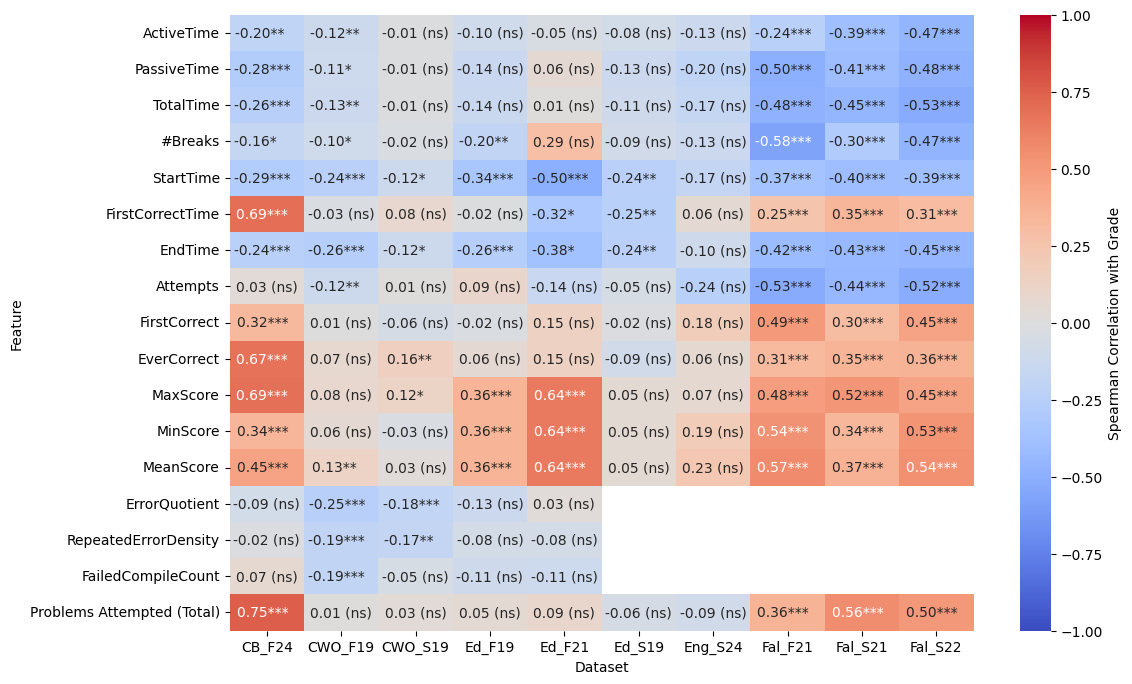

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(data=heat_map_values,
    annot=heat_map_annotations,
    cmap="coolwarm",
    center=0,
    fmt="",
    vmin=-1, vmax=1,
    cbar_kws={"label": "Spearman Correlation with Grade"},
)

<Axes: xlabel='Rho', ylabel='Feature'>

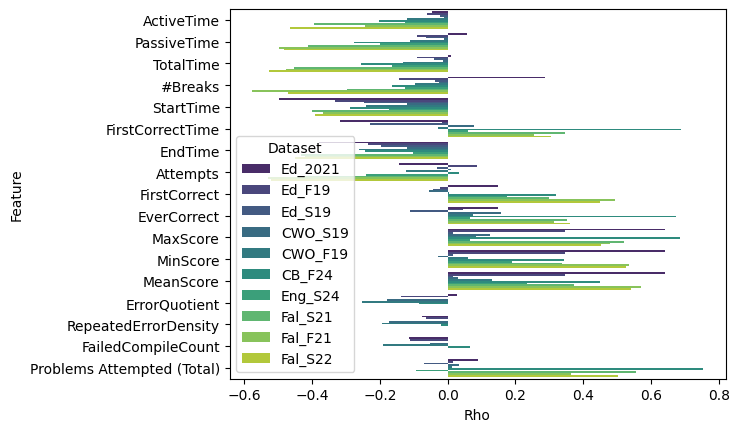

In [102]:
import seaborn as sns

sns.barplot(data=all_data,
    x="Rho",
    y="Feature",
    hue="Dataset",
    dodge=True,
    palette="viridis",
    orient="h",
)

In [ ]:
skip_cols = ["X-ClassID", Cols.SubjectID]
skip_cols = [col for col in skip_cols if col in data.columns]

<Axes: >

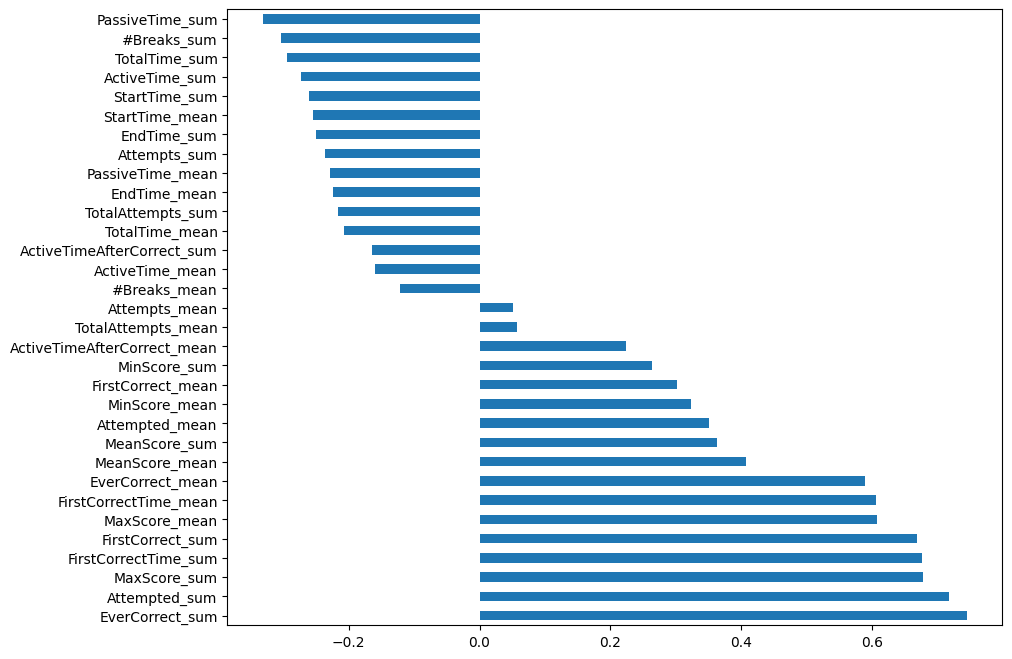

In [ ]:
corrs = data.drop(columns=skip_cols).corr(method="spearman")["Grade"]
corrs = corrs[corrs != 1].sort_values(ascending=False)
corrs.plot(kind='barh', figsize=(10, 8))

In [ ]:
X = data.drop(columns=skip_cols + ['Grade'])
y = data['Grade']

In [9]:
# Drop columns with 0 variance
variance = X.var()
zero_variance_cols = variance[variance == 0].index
print (f"Dropping columns with zero variance: {zero_variance_cols.tolist()}")
X = X.drop(columns=zero_variance_cols)

Dropping columns with zero variance: ['ActiveTimeAfterCorrect_mean', 'ActiveTimeAfterCorrect_sum']


In [10]:
linear_corr = X.corr()
# Find pairs that have correlation above 0.9
corr_pairs = linear_corr[linear_corr != 1].stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = corr_pairs[abs(corr_pairs['Correlation']) > 0.9].reset_index(drop=True)
print("High correlation pairs:")
with pd.option_context('display.max_rows', None):
    print(high_corr_pairs)

High correlation pairs:
                       Feature1                     Feature2  Correlation
0               ActiveTime_mean               TotalTime_mean     0.965812
1               ActiveTime_mean               ActiveTime_sum     0.977075
2               ActiveTime_mean                TotalTime_sum     0.940585
3              PassiveTime_mean               TotalTime_mean     0.958572
4              PassiveTime_mean              PassiveTime_sum     0.980285
5              PassiveTime_mean                TotalTime_sum     0.942590
6                TotalTime_mean              ActiveTime_mean     0.965812
7                TotalTime_mean             PassiveTime_mean     0.958572
8                TotalTime_mean               ActiveTime_sum     0.947427
9                TotalTime_mean              PassiveTime_sum     0.934878
10               TotalTime_mean                TotalTime_sum     0.978603
11                 #Breaks_mean                  #Breaks_sum     0.978775
12            

<Axes: >

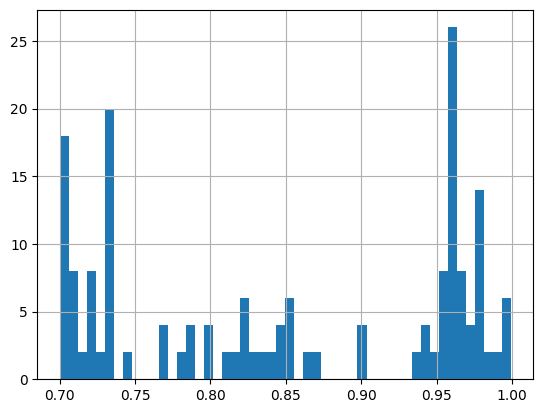

In [11]:
corr_pairs.Correlation[corr_pairs.Correlation > 0.7].hist(bins=50)

In [12]:
# For each highly correlated pair of features, drop the one with the lower
# correlation with the target variable
def drop_low_corr_feature(pair, X, y):
    feature1, feature2 = pair['Feature1'], pair['Feature2']
    corr1 = X[feature1].corr(y)
    corr2 = X[feature2].corr(y)
    if abs(corr1) > abs(corr2):
        return feature2
    else:
        return feature1

to_drop = high_corr_pairs.apply(drop_low_corr_feature, axis=1, X=X, y=y)
print(f"Dropping features with high correlation: {to_drop.tolist()}")
X_lean = X.drop(columns=to_drop)

Dropping features with high correlation: ['ActiveTime_mean', 'ActiveTime_sum', 'TotalTime_sum', 'PassiveTime_mean', 'PassiveTime_sum', 'TotalTime_sum', 'ActiveTime_mean', 'PassiveTime_mean', 'ActiveTime_sum', 'PassiveTime_sum', 'TotalTime_sum', '#Breaks_sum', 'StartTime_sum', 'FirstCorrect_mean', 'EverCorrect_mean', 'FirstCorrectTime_sum', 'EndTime_mean', 'Attempts_mean', 'Attempts_sum', 'TotalAttempts_sum', 'FirstCorrect_mean', 'EverCorrect_mean', 'Attempts_mean', 'TotalAttempts_mean', 'Attempts_sum', 'TotalAttempts_sum', 'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'TotalAttempts_mean', 'Attempts_sum', 'TotalAttempts_sum', 'RepeatedErrorDensity_mean', 'FailedCompileCount_mean', 'AtLeatMedianActiveTime_sum', 'AtLeatMedianMaxScore_sum', 'HadEffort_sum', 'ActiveTime_sum', 'ActiveTime_sum', 'ActiveTime_sum', 'PassiveTime_sum', 'PassiveTime_sum', 'TotalTime_sum', 'TotalTime_sum', 'TotalTi

In [13]:
X_lean.columns

Index(['TotalTime_mean', '#Breaks_mean', 'StartTime_mean',
       'FirstCorrectTime_mean', 'Attempted_mean', 'MaxScore_mean',
       'MinScore_mean', 'MeanScore_mean', 'ErrorQuotient_mean',
       'AtLeatMedianActiveTime_mean', 'AtLeatMedianMaxScore_mean',
       'HadEffort_mean', 'EndTime_sum', 'FirstCorrect_sum', 'EverCorrect_sum',
       'Attempted_sum', 'ErrorQuotient_sum', 'RepeatedErrorDensity_sum',
       'FailedCompileCount_sum'],
      dtype='object')

In [ ]:
# Use the original data to peak at Grade
data.drop(columns=to_drop).drop(columns=skip_cols).corr(method='spearman')

,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,Attempted_mean,MaxScore_mean,MinScore_mean,MeanScore_mean,ErrorQuotient_mean,...,HadEffort_mean,ActiveTimeAfterCorrect_sum,EndTime_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,Grade
TotalTime_mean,1.000000,NaN,0.727732,-0.347213,0.102439,0.156797,0.232299,0.232299,0.232299,-0.108490,...,0.573165,NaN,0.188502,0.271901,0.271901,0.284463,-0.076804,-0.087355,0.558014,0.010105
ActiveTimeAfterCorrect_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
#Breaks_mean,0.727732,NaN,1.000000,-0.602901,-0.022562,-0.017267,0.342272,0.342272,0.342272,-0.076697,...,0.384178,NaN,0.014896,0.254754,0.254754,0.225758,-0.042272,-0.039511,0.368744,0.287643
StartTime_mean,-0.347213,NaN,-0.602901,1.000000,0.322997,0.149331,-0.461807,-0.461807,-0.461807,0.150924,...,-0.377014,NaN,0.513763,-0.206786,-0.206786,-0.055678,0.142060,0.063432,-0.088153,-0.496167
FirstCorrectTime_mean,0.102439,NaN,-0.022562,0.322997,1.000000,0.373327,-0.007674,-0.007674,-0.007674,0.238813,...,-0.090333,NaN,0.434146,0.153989,0.153989,-0.167033,0.267525,0.269678,0.144599,-0.311324
Attempted_mean,0.156797,NaN,-0.017267,0.149331,0.373327,1.000000,0.317193,0.317193,0.317193,-0.091470,...,0.257389,NaN,0.099398,0.412479,0.412479,0.501652,-0.097909,-0.145638,0.120865,0.088198
MaxScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
MinScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
MeanScore_mean,0.232299,NaN,0.342272,-0.461807,-0.007674,0.317193,1.000000,1.000000,1.000000,-0.208914,...,0.677806,NaN,-0.279037,0.487556,0.487556,0.287801,-0.229082,-0.218798,0.016393,0.627834
ErrorQuotient_mean,-0.108490,NaN,-0.076697,0.150924,0.238813,-0.091470,-0.208914,-0.208914,-0.208914,1.000000,...,-0.207970,NaN,-0.188431,-0.400091,-0.400091,-0.595279,0.993228,0.818333,0.259974,0.028102


In [15]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.25, random_state=42)

In [16]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    # 'n_estimators': [50, 100, 200, 350, 500],
    'n_estimators': [10, 20, 50, 100, 200],
    'max_depth': [1, 5, 10, 20, 30],
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_absolute_error', return_train_score=True)

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'max_depth': 5, 'n_estimators': 200}


In [17]:
pd.DataFrame(grid_search.cv_results_)[["mean_train_score", "mean_test_score", "std_test_score", "params"]]

,mean_train_score,mean_test_score,std_test_score,params
0,-6.841851,-11.540605,4.224044,"{'max_depth': 1, 'n_estimators': 10}"
1,-6.599704,-11.298883,3.847665,"{'max_depth': 1, 'n_estimators': 20}"
2,-6.494332,-11.312684,3.730622,"{'max_depth': 1, 'n_estimators': 50}"
3,-6.552314,-11.352373,3.727654,"{'max_depth': 1, 'n_estimators': 100}"
4,-6.427500,-11.133114,3.815339,"{'max_depth': 1, 'n_estimators': 200}"
5,-4.146189,-11.231377,4.107577,"{'max_depth': 5, 'n_estimators': 10}"
6,-3.577173,-10.908503,4.044078,"{'max_depth': 5, 'n_estimators': 20}"
7,-3.497982,-10.940448,3.774897,"{'max_depth': 5, 'n_estimators': 50}"
8,-3.710473,-10.837427,3.660293,"{'max_depth': 5, 'n_estimators': 100}"
9,-3.753827,-10.696553,3.730171,"{'max_depth': 5, 'n_estimators': 200}"


<Axes: xlabel='mean_train_score', ylabel='mean_test_score'>

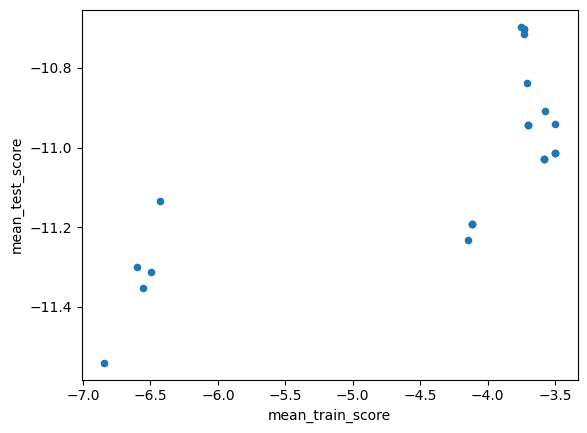

In [18]:
pd.DataFrame(grid_search.cv_results_).plot.scatter("mean_train_score", "mean_test_score")

In [19]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

# Create a table of each feature and its coefficient
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_,
    'Abs_Coefficient': abs(lasso.coef_)
})
lasso_coef.sort_values(by='Abs_Coefficient', ascending=False)


,Feature,Coefficient,Abs_Coefficient
11,HadEffort_mean,7.966799e+00,7.966799e+00
5,MaxScore_mean,1.352861e+00,1.352861e+00
4,Attempted_mean,-1.053030e+00,1.053030e+00
10,AtLeatMedianMaxScore_mean,5.905328e-02,5.905328e-02
6,MinScore_mean,1.072991e-14,1.072991e-14
0,TotalTime_mean,0.000000e+00,0.000000e+00
1,#Breaks_mean,0.000000e+00,0.000000e+00
2,StartTime_mean,-0.000000e+00,0.000000e+00
3,FirstCorrectTime_mean,-0.000000e+00,0.000000e+00
8,ErrorQuotient_mean,0.000000e+00,0.000000e+00


In [20]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
gb_grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='neg_mean_absolute_error')
gb_grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [21]:
pd.DataFrame(gb_grid_search.cv_results_)[["mean_test_score", "std_test_score", "params"]]

,mean_test_score,std_test_score,params
0,-9.740522,3.692831,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
1,-9.830861,3.655241,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
2,-9.768446,3.620371,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
3,-9.828029,3.514749,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
4,-9.723163,3.619472,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
5,-9.910764,3.775390,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
6,-9.844616,3.658429,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
7,-9.942036,3.587417,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
8,-10.314312,3.569140,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
9,-10.346695,3.520657,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

print(mean_absolute_error(y_test, grid_search.predict(X_test)))
print(r2_score(y_test, grid_search.predict(X_test)))

12.52440738577527
-6.830668869258588


In [23]:
print(mean_absolute_error(y_test, lasso.predict(X_test)))
print(r2_score(y_test, lasso.predict(X_test)))

10.900435199452081
-4.1519921563671796


In [24]:
print(mean_absolute_error(y_test, gb_grid_search.predict(X_test)))
print(r2_score(y_test, gb_grid_search.predict(X_test)))

9.511603778705144
-5.777160953194817


In [26]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X_train[['EverCorrect_sum']], y_train)

ever_correct_baseline = linear_reg.predict(X_test[['EverCorrect_sum']])
print(mean_absolute_error(y_test, ever_correct_baseline))
print(r2_score(y_test, ever_correct_baseline))

7.511927710843387
-1.1477574057649993


In [25]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)

print(mean_absolute_error(y_test, dummy_regressor.predict(X_test)))
print(r2_score(y_test, dummy_regressor.predict(X_test)))

5.809545454545468
-0.23218936399607681


<Axes: >

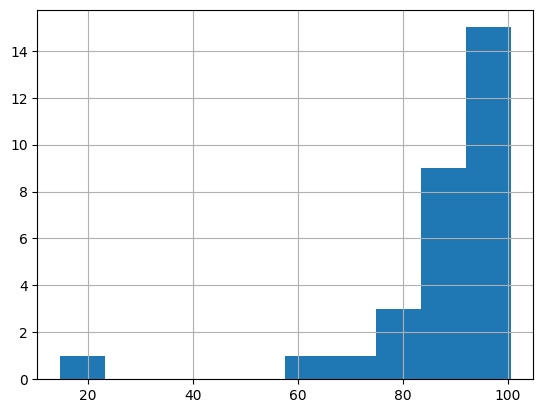

In [27]:
y_train.hist()

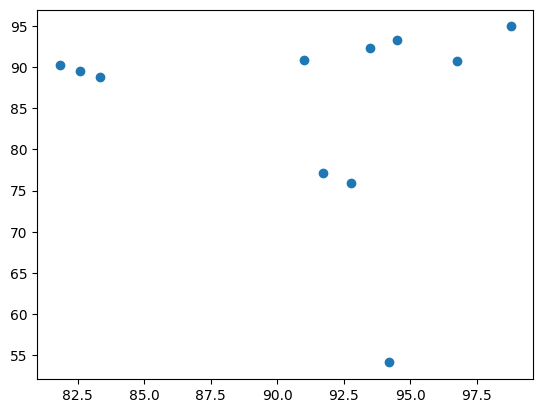

In [28]:
plt.scatter(y_test, gb_grid_search.predict(X_test))

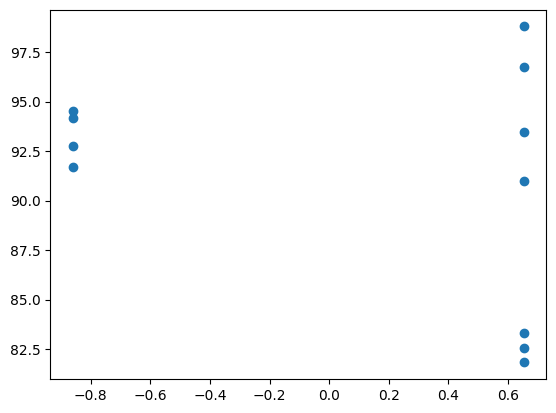

In [29]:
plt.scatter(X_test['EverCorrect_sum'], y_test)